# Pair Trading Strategy

## 1. Data Collection
We download daily closing prices for AAPL and MSFT using yfinance.

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import compute_zscore  

# Select assets
tickers = ["AAPL", "MSFT"]

# Download Data
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")["Close"]

# Cleand data
data.dropna(inplace=True)

[*********************100%***********************]  2 of 2 completed


## 2. Spred Construction
We define the spread as the difference between the prices of the two assets.

In [3]:
data["spread"] = data[tickers[0]] - data[tickers[1]]

## 3. Z-Score Normalization
The spread is normalized using a z-score to identify deviations from the mean.

In [4]:
data["zscore"] = compute_zscore(data["spread"])

## 4. Signal Generation
We generate trading signals based on z-score thresholds.

In [5]:
entry_threshold = 1.0
exit_threshold = 0.0

data['position'] = 0

# Entry signals
data.loc[data["zscore"] > entry_threshold, "position"] = -1
data.loc[data["zscore"] < -entry_threshold, "position"] = 1

# Forward fill positions
data["position"] = data["position"].ffill()

# Exit signals
data.loc[data["zscore"].abs() < exit_threshold, "position"] = 0

## 5. Backtest
We compute strategy return based on spread changes and positions.

In [6]:
# Spread returns
data["spread_returns"] = data["spread"].diff()

# Strategy returns
data["strategy_returns"] = data["position"].shift(1) * data["spread_returns"]

# Cumulative strategy returns
data["cumulative_strategy_returns"] = data["strategy_returns"].cumsum()

## 6. Results
We visualize the spread, z-score and cumulative returns.

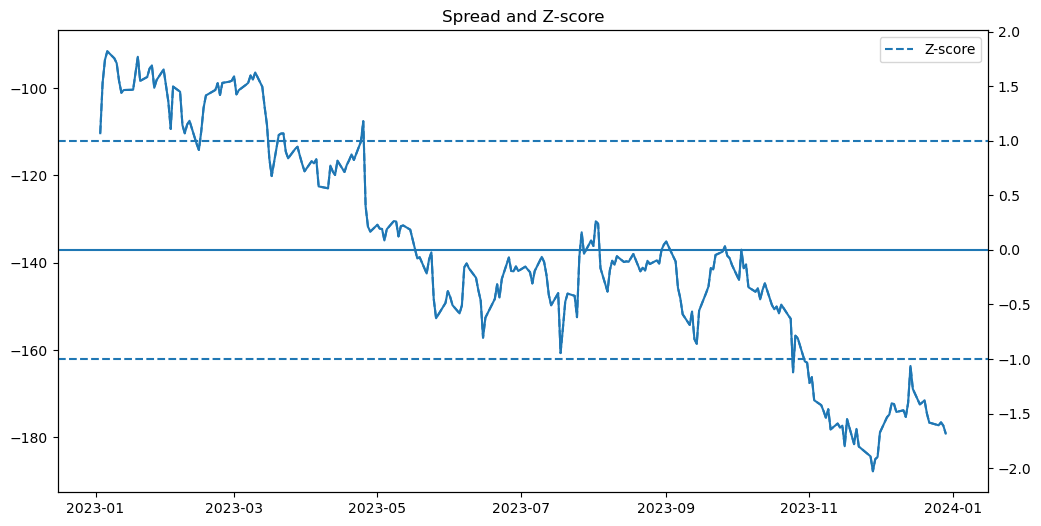

In [7]:
plt.figure(figsize=(12,6))

# Spread
plt.plot(data['spread'], label='Spread')

# Z-score and second axis
ax2 = plt.gca().twinx()
ax2.plot(data["zscore"], linestyle="--", label="Z-score")

# Thresholds
ax2.axhline(1.0, linestyle="--")
ax2.axhline(-1.0, linestyle="--")
ax2.axhline(0)

plt.title("Spread and Z-score")
plt.legend(loc="upper left")
ax2.legend(loc="upper right")

# Save figure in figures/ folder
plt.savefig("figures/spread_zscore.png", bbox_inches='tight')

plt.show()

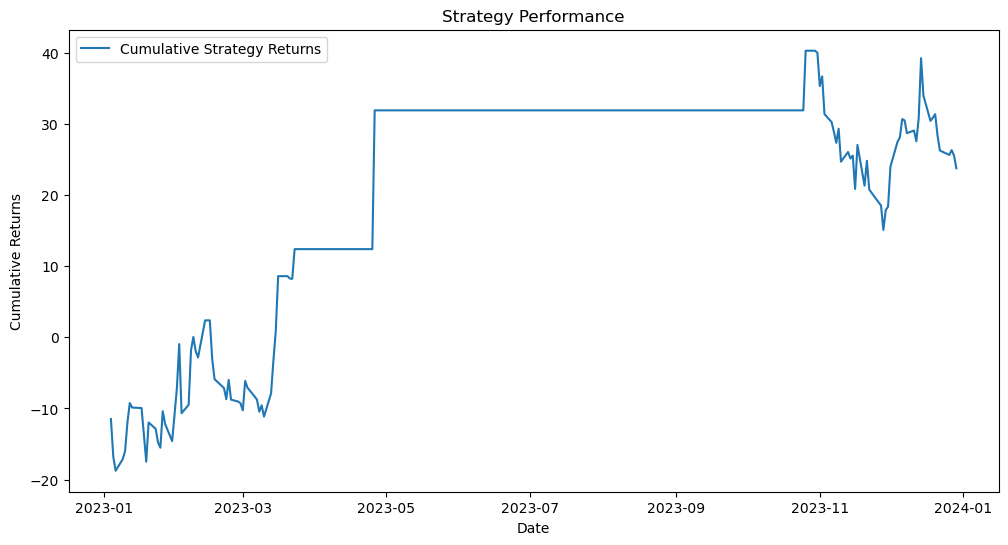

In [8]:
plt.figure(figsize=(12,6))

plt.plot(data['cumulative_strategy_returns'], label='Cumulative Strategy Returns')

plt.title("Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()

# Save figure in figures/ folder
plt.savefig("figures/cumulative_returns.png", bbox_inches='tight')

plt.show()